# Notebook 1 — Tokenizer Fragmentation Analysis for Numerical Expressions

**Case Study 1.9**: Tokenization of Numerical Expressions and Structured Data.

## Goal of this notebook

This notebook answers the **first** research question of the case study:

> *How do different tokenization strategies (word-level, BPE, WordPiece, SentencePiece) segment numerical expressions and structured data (dates, times, currency, percentages, scientific notation, fractions)?*

Concretely, we will measure:

1. **Fragmentation**: how many sub-tokens a single numerical expression gets split into, per tokenizer and per category.
2. **Sequence-length inflation**: how much longer a real-world numeric-heavy sentence becomes under each tokenizer.
3. **Vocabulary coverage**: are frequent numbers (e.g. `100`, `2024`) stored as single vocabulary tokens, or always split?
4. **Per-digit consistency**: which tokenizers apply digit-level splitting (1 token per digit), and which produce irregular splits that vary with magnitude?

## Why this matters

Numerical expressions are a tiny fraction of training data but are disproportionately important for finance, science, QA, and reasoning tasks. If a tokenizer splits `1,234,567` into 5 sub-tokens but `1234567` into 2, the model sees the *same quantity* as two completely different token sequences — which directly hurts numerical reasoning and generalization. Recent work (GPT-3, LLaMA-3, Qwen, DeepSeek) has moved toward **digit-level tokenization** specifically because of this.

## Hardware

**CPU-only.** We only load *tokenizers*, not model weights. Runs in a few minutes on a laptop.


## 0. Setup

Install dependencies (uncomment the pip line if running in a fresh Colab/Kaggle environment).

In [1]:
# !pip install transformers sentencepiece tiktoken matplotlib seaborn pandas --quiet

import warnings
warnings.filterwarnings("ignore")

import math
import json
import random
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random.seed(0)
np.random.seed(0)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110


## 1. Load tokenizers

We compare **8 tokenizers** spanning the main families:

| Family                  | Representative          | Vocab type        |
|-------------------------|-------------------------|-------------------|
| WordPiece               | `bert-base-uncased`     | subword           |
| Byte-level BPE          | `gpt2`                  | subword (bytes)   |
| Byte-level BPE          | `roberta-base`          | subword (bytes)   |
| Byte-level BPE (large)  | `bigscience/bloom-560m` | multilingual      |
| SentencePiece Unigram   | `t5-base`               | subword (SP)      |
| SentencePiece Unigram   | `xlm-roberta-base`      | multilingual      |
| GPT-NeoX BPE            | `EleutherAI/pythia-160m`| byte-level BPE (*advertised* digit-split — we test this) |
| OPT BPE                 | `facebook/opt-125m`     | byte-level BPE    |
| Qwen2 BPE (digit)       | `Qwen/Qwen2.5-0.5B`     | **byte-level BPE with real digit-level pre-tokenization** |

The GPT-NeoX family is often described as using digit-level tokenization; we will *measure* whether Pythia-160m actually does. Qwen2.5's tokenizer, by contrast, has confirmed per-digit pre-tokenization in its official documentation and serves as our real digit-level reference.

All of these are **publicly available** on the Hugging Face Hub (no auth required).

In [2]:
from transformers import AutoTokenizer

TOKENIZER_SPECS = [
    ("BERT",      "bert-base-uncased",        "WordPiece"),
    ("GPT-2",     "gpt2",                     "Byte-BPE"),
    ("RoBERTa",   "roberta-base",             "Byte-BPE"),
    ("BLOOM",     "bigscience/bloom-560m",    "Byte-BPE (multi)"),
    ("T5",        "t5-base",                  "SentencePiece"),
    ("XLM-R",     "xlm-roberta-base",         "SentencePiece (multi)"),
    ("Pythia",    "EleutherAI/pythia-160m",   "GPT-NeoX BPE (digit)"),
    ("OPT",       "facebook/opt-125m",        "Byte-BPE"),
    ("Qwen2.5",   "Qwen/Qwen2.5-0.5B",        "Byte-BPE (digit)"),   # REAL digit-level tokenizer
]

tokenizers = {}
families = {}
for nick, hf_name, family in TOKENIZER_SPECS:
    try:
        tokenizers[nick] = AutoTokenizer.from_pretrained(hf_name, use_fast=True)
        families[nick] = family
        print(f"✓ loaded {nick:10s}  ({hf_name}, vocab={len(tokenizers[nick]):>6d})")
    except Exception as e:
        print(f"✗ failed {nick}: {type(e).__name__}: {e}")

print(f"\nReady: {len(tokenizers)} tokenizers.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ loaded BERT        (bert-base-uncased, vocab= 30522)


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✓ loaded Qwen2.5     (Qwen/Qwen2.5-0.5B, vocab=151665)

Ready: 9 tokenizers.


### Helper: uniform token count

Different tokenizers handle leading whitespace differently (byte-level BPE marks it with `Ġ`, SentencePiece with `▁`). To compare fairly we:

1. Tokenize the raw string **without** adding any special tokens (`[CLS]`, `</s>`, …).
2. For byte-level tokenizers we also strip the space-prefix artifact by passing the string as-is — but we count *all* produced sub-tokens, because those artifacts *do* count toward sequence length in practice.

In [3]:
def token_count(tok, text: str) -> int:
    """Number of sub-tokens produced for `text`, excluding special tokens."""
    ids = tok.encode(text, add_special_tokens=False)
    return len(ids)

def token_pieces(tok, text: str):
    """Return list of sub-token strings (for inspection)."""
    ids = tok.encode(text, add_special_tokens=False)
    return tok.convert_ids_to_tokens(ids)

# Sanity check
for nick in list(tokenizers)[:3]:
    print(f"{nick:8s} '1,234,567' -> {token_pieces(tokenizers[nick], '1,234,567')}")


BERT     '1,234,567' -> ['1', ',', '234', ',', '56', '##7']
GPT-2    '1,234,567' -> ['1', ',', '234', ',', '5', '67']
RoBERTa  '1,234,567' -> ['1', ',', '234', ',', '5', '67']


## 2. Test corpus of numerical expressions

We build a **categorized** test corpus with 8 categories. Each category has ~15–25 examples to make averages stable.

In [4]:
CORPUS = {
    "Plain integers": [
        "0", "7", "42", "100", "256", "999",
        "1000", "2024", "10000", "65536",
        "100000", "1000000", "1234567", "10000000",
        "123456789", "9999999999",
    ],
    "Formatted integers (commas)": [
        "1,000", "10,000", "100,000", "1,000,000",
        "1,234", "12,345", "123,456", "1,234,567",
        "10,000,000", "1,000,000,000",
    ],
    "Decimals": [
        "0.1", "0.5", "1.5", "3.14", "3.14159", "2.71828",
        "0.001", "12.5", "99.99", "1234.5678", "0.000001",
    ],
    "Scientific notation": [
        "1e5", "1e-5", "1.2e-5", "6.022e23", "2.5e10",
        "1.0E+8", "3.14e0", "9.81e-2", "1e100",
    ],
    "Dates": [
        "2024-01-15", "2026-03-01", "1999-12-31",
        "2024/01/15", "03/01/2026", "15-Jan-2024",
        "January 15, 2024", "Jan 15 2024", "15.03.2026",
    ],
    "Times": [
        "10:45", "10:45 PM", "23:59:59", "00:00",
        "9:15 AM", "14:30", "12:00:00",
        "10:45:30.125", "1h30m",
    ],
    "Currency": [
        "$5", "$19.99", "$1,200", "$1,234,567.89",
        "€100", "€1,200.50", "£50", "£1,000",
        "¥10000", "¥100,000", "USD 1000", "EUR 50.00",
    ],
    "Percentages": [
        "5%", "12.5%", "100%", "0.5%",
        "99.99%", "0.001%", "-3.5%", "+12%",
    ],
    "Fractions": [
        "1/2", "3/4", "22/7", "1/3", "7/8",
        "1/100", "99/100", "355/113",
    ],
}

total = sum(len(v) for v in CORPUS.values())
print(f"{len(CORPUS)} categories, {total} expressions total")


9 categories, 92 expressions total


## 3. Side-by-side examples

Before aggregating, let's **look at the actual output** for a few representative expressions. This is the most illuminating part of the notebook.

In [5]:
def show_side_by_side(examples, max_tokens_display=12):
    rows = []
    for ex in examples:
        row = {"text": ex}
        for nick, tok in tokenizers.items():
            pieces = token_pieces(tok, ex)
            n = len(pieces)
            # Display sub-tokens compactly; truncate if very long
            disp = "·".join(pieces[:max_tokens_display])
            if n > max_tokens_display:
                disp += f" …(+{n - max_tokens_display})"
            row[nick] = f"[{n}] {disp}"
        rows.append(row)
    return pd.DataFrame(rows).set_index("text")

highlights = [
    "1000000", "1,000,000", "1234567",
    "3.14159", "1.2e-5",
    "2026-03-01", "10:45 PM",
    "$19.99", "€1,200",
    "12.5%", "3/4",
]
with pd.option_context("display.max_colwidth", 60):
    display(show_side_by_side(highlights))


,BERT,GPT-2,RoBERTa,BLOOM,T5,XLM-R,Pythia,OPT,Qwen2.5
text,,,,,,,,,
1000000,[3] 1000·##00·##0,[2] 1·000000,[2] 1·000000,[2] 1·000000,[2] ▁1000·000,[2] ▁100·0000,[2] 1·000000,[2] 1·000000,[7] 1·0·0·0·0·0·0
"1,000,000","[5] 1·,·000·,·000","[5] 1·,·000·,·000","[5] 1·,·000·,·000","[5] 1·,·000·,·000","[2] ▁1·,000,000","[2] ▁1·,000,000","[5] 1·,·000·,·000","[5] 1·,·000·,·000","[9] 1·,·0·0·0·,·0·0·0"
1234567,[4] 123·##45·##6·##7,[3] 123·45·67,[3] 123·45·67,[2] 12345·67,[4] ▁·123·45·67,[3] ▁·1234·567,[2] 12345·67,[3] 123·45·67,[7] 1·2·3·4·5·6·7
3.14159,[4] 3·.·141·##59,[4] 3·.·14·159,[4] 3·.·14·159,[4] 3·.·14·159,[3] ▁3.·14·159,[3] ▁3.·14·159,[4] 3·.·14·159,[4] 3·.·14·159,[7] 3·.·1·4·1·5·9
1.2e-5,[6] 1·.·2·##e·-·5,[6] 1·.·2·e·-·5,[6] 1·.·2·e·-·5,[4] 1·.·2e·-5,[4] ▁·1.2·e·-5,[3] ▁1.2·e·-5,[6] 1·.·2·e·-·5,[6] 1·.·2·e·-·5,[6] 1·.·2·e·-·5
2026-03-01,[6] 202·##6·-·03·-·01,[6] 20·26·-·03·-·01,[6] 20·26·-·03·-·01,[4] 202·6·-03·-01,[5] ▁20·26·-·03·-01,[4] ▁20·26·-03-·01,[6] 20·26·-·03·-·01,[6] 20·26·-·03·-·01,[10] 2·0·2·6·-·0·3·-·0·1
10:45 PM,[4] 10·:·45·pm,[4] 10·:·45·ĠPM,[4] 10·:·45·ĠPM,[3] 10·:45·ĠPM,[4] ▁10·:·45·▁PM,[3] ▁10·:45·▁PM,[4] 10·:·45·ĠPM,[4] 10·:·45·ĠPM,[6] 1·0·:·4·5·ĠPM
$19.99,[4] $·19·.·99,[4] $·19·.·99,[4] $·19·.·99,[4] $·19·.·99,[2] ▁$1·9.99,[2] ▁$1·9.99,[4] $·19·.·99,[4] $·19·.·99,[6] $·1·9·.·9·9
"€1,200","[4] €·##1·,·200","[4] âĤ¬·1·,·200","[4] âĤ¬·1·,·200","[4] âĤ¬·1·,·200","[3] ▁€·1,·200","[4] ▁€·1·,·200","[4] âĤ¬·1·,·200","[4] âĤ¬·1·,·200","[6] âĤ¬·1·,·2·0·0"


**Observations to watch for:**

- Same number written differently (`1000000` vs `1,000,000`) → very different token counts on most tokenizers.
- `Pythia` should produce **one token per digit** — this is a deliberate design choice.
- `BERT` cannot handle some characters (€, ¥) cleanly — watch for `[UNK]` or byte fallback.
- Dates like `2026-03-01` often collapse into a few merged sub-tokens because `2024`-ish years are common substrings in training data.


## 4. Average fragmentation per category

Now we aggregate. For each `(tokenizer, category)` pair we compute the **mean number of sub-tokens per expression**.

In [6]:
def build_fragmentation_table():
    records = []
    for nick, tok in tokenizers.items():
        for cat, examples in CORPUS.items():
            counts = [token_count(tok, ex) for ex in examples]
            records.append({
                "tokenizer": nick,
                "family": families[nick],
                "category": cat,
                "mean_tokens": np.mean(counts),
                "median_tokens": np.median(counts),
                "max_tokens": np.max(counts),
                "n": len(counts),
            })
    return pd.DataFrame(records)

frag_df = build_fragmentation_table()
frag_df.head(10)


,tokenizer,family,category,mean_tokens,median_tokens,max_tokens,n
0,BERT,WordPiece,Plain integers,2.500000,2.0,8,16
1,BERT,WordPiece,Formatted integers (commas),4.200000,3.5,7,10
2,BERT,WordPiece,Decimals,3.727273,3.0,6,11
3,BERT,WordPiece,Scientific notation,4.888889,5.0,6,9
4,BERT,WordPiece,Dates,5.555556,6.0,6,9
5,BERT,WordPiece,Times,4.222222,4.0,7,9
6,BERT,WordPiece,Currency,3.833333,3.5,9,12
7,BERT,WordPiece,Percentages,3.500000,4.0,5,8
8,BERT,WordPiece,Fractions,3.000000,3.0,3,8
9,GPT-2,Byte-BPE,Plain integers,1.750000,1.5,4,16


In [7]:
# Pivot to a heatmap-friendly matrix
mat = frag_df.pivot(index="tokenizer", columns="category", values="mean_tokens")
# Preserve our tokenizer order
mat = mat.reindex([n for n, _, _ in TOKENIZER_SPECS if n in mat.index])
mat = mat[list(CORPUS.keys())]
mat.round(2)


category,Plain integers,Formatted integers (commas),Decimals,Scientific notation,Dates,Times,Currency,Percentages,Fractions
tokenizer,,,,,,,,,
BERT,2.50,4.2,3.73,4.89,5.56,4.22,3.83,3.50,3.00
GPT-2,1.75,4.1,3.45,4.78,5.33,4.22,4.00,3.50,3.00
RoBERTa,1.75,4.1,3.45,4.78,5.33,4.22,4.00,3.50,3.00
BLOOM,1.44,4.0,3.27,3.78,4.11,2.67,3.42,2.50,1.88
T5,2.25,2.4,2.64,3.78,4.33,4.00,3.17,2.38,2.12
XLM-R,1.75,2.3,2.09,3.56,3.89,2.78,3.17,2.12,1.88
Pythia,1.44,4.0,3.27,4.78,5.56,4.22,3.75,3.50,3.00
OPT,1.75,4.1,3.45,4.78,5.33,4.22,4.00,3.50,3.00
Qwen2.5,4.88,7.7,5.27,5.67,9.67,6.56,6.33,4.50,4.25


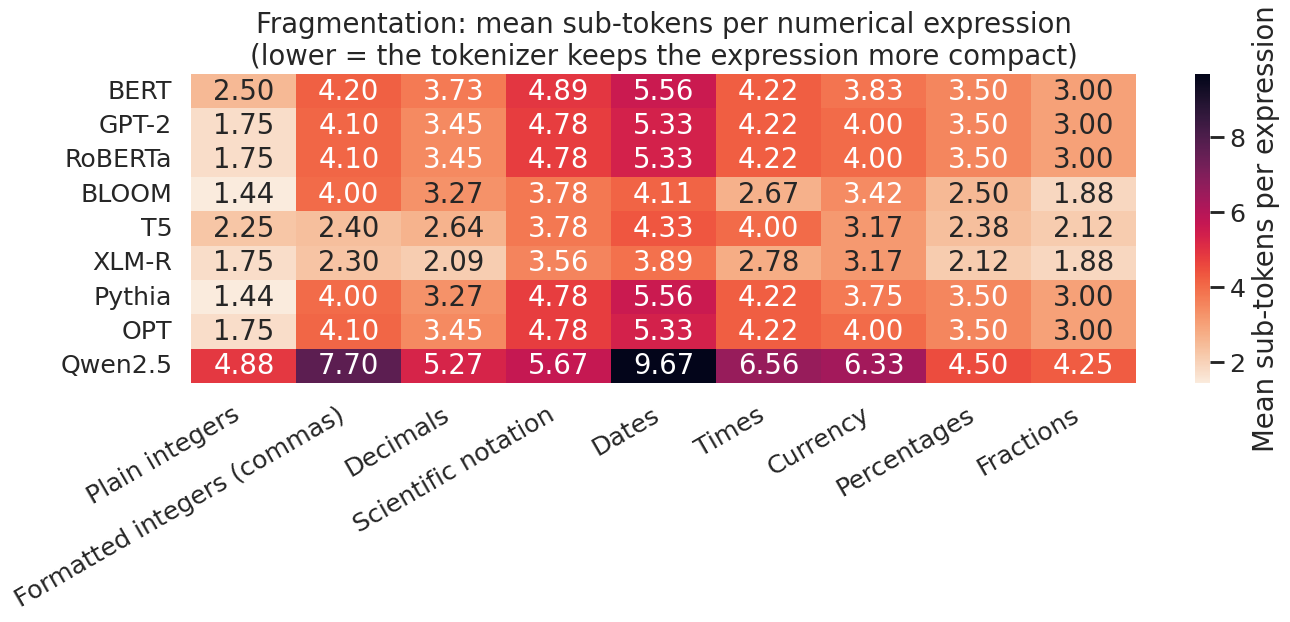

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    mat,
    annot=True, fmt=".2f",
    cmap="rocket_r",
    cbar_kws={"label": "Mean sub-tokens per expression"},
    ax=ax,
)
ax.set_title("Fragmentation: mean sub-tokens per numerical expression\n(lower = the tokenizer keeps the expression more compact)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("fig_fragmentation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### What to read off this heatmap

- **Columns** with consistently high numbers (e.g. *Formatted integers*, *Scientific notation*) are the hardest categories — commas and `e-` break every merge pattern the tokenizer learned.
- **Rows** with the lowest numbers tokenize most efficiently — but remember: *efficient ≠ good for reasoning*. A compact token like `1,000,000` gives the model no structural handle on the digits.
- Pythia should stand out in the opposite direction — high token counts everywhere, because it splits digit-by-digit. This is actually the *feature* that enables better numerical generalization (we'll test this in Notebook 4).


## 5. Deep dive: integers from 0 to 10,000

How does fragmentation scale with the **magnitude** of an integer? We tokenize every integer from 0 to 9,999 and plot the distribution.

In [9]:
RANGE_MAX = 10_000  # covers 1-, 2-, 3-, 4-digit numbers

range_records = []
for nick, tok in tokenizers.items():
    for n in range(RANGE_MAX):
        range_records.append({
            "tokenizer": nick,
            "n": n,
            "digits": len(str(n)),
            "tokens": token_count(tok, str(n)),
        })
range_df = pd.DataFrame(range_records)
print(range_df.groupby("tokenizer")["tokens"].describe().round(2))


             count  mean   std  min  25%  50%  75%  max
tokenizer                                              
BERT       10000.0  2.11  0.52  1.0  2.0  2.0  2.0  3.0
BLOOM      10000.0  1.88  0.33  1.0  2.0  2.0  2.0  2.0
GPT-2      10000.0  1.91  0.29  1.0  2.0  2.0  2.0  3.0
OPT        10000.0  1.91  0.29  1.0  2.0  2.0  2.0  3.0
Pythia     10000.0  1.90  0.30  1.0  2.0  2.0  2.0  2.0
Qwen2.5    10000.0  3.89  0.35  1.0  4.0  4.0  4.0  4.0
RoBERTa    10000.0  1.91  0.29  1.0  2.0  2.0  2.0  3.0
T5         10000.0  2.23  0.47  1.0  2.0  2.0  3.0  3.0
XLM-R      10000.0  1.95  0.22  1.0  2.0  2.0  2.0  2.0


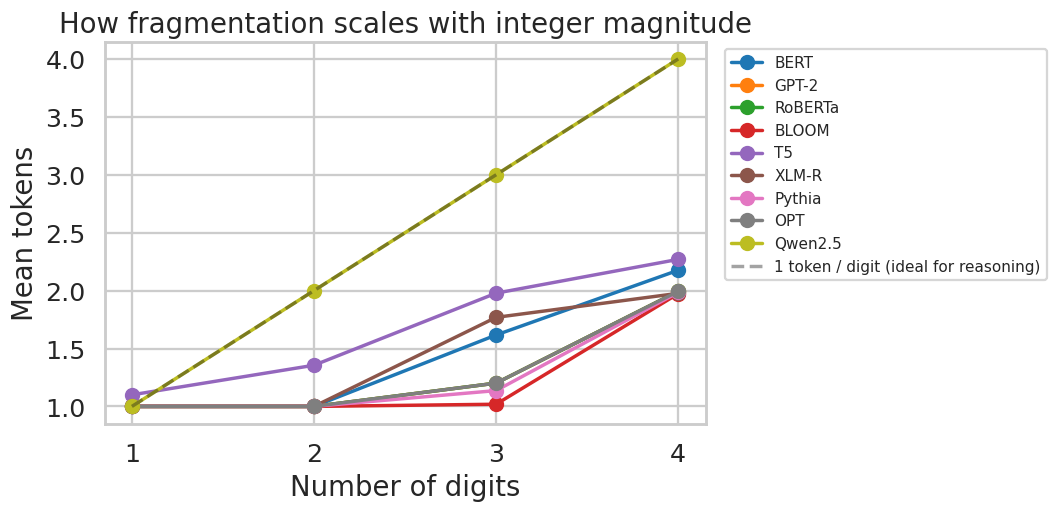

In [10]:
# Mean tokens per number of digits — reveals per-digit vs. merged patterns
agg = (range_df.groupby(["tokenizer", "digits"])["tokens"]
                .mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
order = [n for n, _, _ in TOKENIZER_SPECS if n in tokenizers]
palette = sns.color_palette("tab10", n_colors=len(order))
for i, nick in enumerate(order):
    sub = agg[agg["tokenizer"] == nick]
    ax.plot(sub["digits"], sub["tokens"], marker="o", label=nick, color=palette[i])

# Reference line: "one token per digit"
ax.plot([1, 2, 3, 4], [1, 2, 3, 4], "k--", alpha=0.4, label="1 token / digit (ideal for reasoning)")

ax.set_xlabel("Number of digits")
ax.set_ylabel("Mean tokens")
ax.set_title("How fragmentation scales with integer magnitude")
ax.set_xticks([1, 2, 3, 4])
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig("fig_digits_vs_tokens.png", dpi=150, bbox_inches="tight")
plt.show()


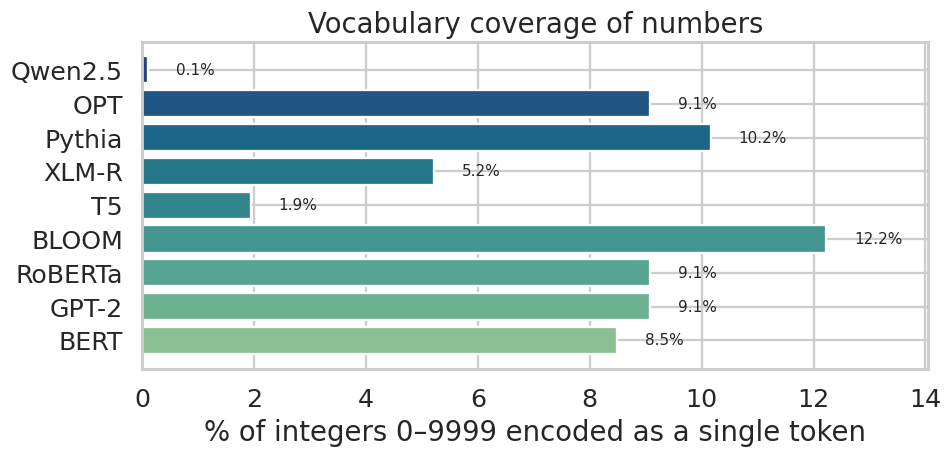

In [11]:
# Fraction of numbers encoded as a SINGLE token, per tokenizer
single_tok = (range_df.assign(is_single=range_df["tokens"] == 1)
                      .groupby("tokenizer")["is_single"].mean()
                      .reindex([n for n, _, _ in TOKENIZER_SPECS if n in tokenizers])
                      * 100)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(single_tok.index, single_tok.values, color=sns.color_palette("crest", len(single_tok)))
for bar, val in zip(bars, single_tok.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=10)
ax.set_xlabel("% of integers 0–9999 encoded as a single token")
ax.set_title("Vocabulary coverage of numbers")
ax.set_xlim(0, max(single_tok.max() * 1.15, 10))
plt.tight_layout()
plt.savefig("fig_single_token_coverage.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretation

- **High single-token coverage** (BERT, XLM-R, T5, BLOOM) means many small integers are atomic. Good for sequence length, *bad* for arithmetic — the model has to memorize a lookup table between token-IDs and magnitudes.
- **Near-zero single-token coverage** (Pythia) means the model must *compose* every number from digits. Harder token economy, but the embedding layer only has to represent 10 digit tokens, and arithmetic becomes regular.
- **Erratic step functions** (GPT-2, RoBERTa, OPT) come from BPE's greedy merging: `123` might be one token because `123` appeared in training, but `124` is two tokens. This is the core problem digit-level tokenization fixes.


## 6. Which common numbers are in the vocabulary?

We check, for a small set of "important" numbers, whether they sit in the vocabulary as a single token.

In [12]:
IMPORTANT_NUMBERS = [
    "100", "1000", "10000", "100000", "1000000",
    "2020", "2023", "2024", "2025", "2026",  # years
    "50", "99", "365",
]

vocab_hits = []
for nick, tok in tokenizers.items():
    row = {"tokenizer": nick}
    for num in IMPORTANT_NUMBERS:
        row[num] = "✓" if token_count(tok, num) == 1 else f"×({token_count(tok, num)})"
    vocab_hits.append(row)
pd.DataFrame(vocab_hits).set_index("tokenizer")


,100,1000,10000,100000,1000000,2020,2023,2024,2025,2026,50,99,365
tokenizer,,,,,,,,,,,,,
BERT,✓,✓,×(2),×(2),×(3),✓,×(2),×(2),×(2),×(2),✓,✓,✓
GPT-2,✓,✓,✓,×(2),×(2),✓,×(2),×(2),×(2),×(2),✓,✓,✓
RoBERTa,✓,✓,✓,×(2),×(2),✓,×(2),×(2),×(2),×(2),✓,✓,✓
BLOOM,✓,✓,✓,✓,×(2),✓,×(2),×(2),×(2),×(2),✓,✓,✓
T5,✓,✓,×(2),×(2),×(2),✓,×(2),×(2),×(2),×(2),✓,✓,×(2)
XLM-R,✓,✓,✓,×(2),×(2),✓,✓,×(2),✓,×(2),✓,✓,✓
Pythia,✓,✓,✓,✓,×(2),✓,×(2),×(2),×(2),×(2),✓,✓,✓
OPT,✓,✓,✓,×(2),×(2),✓,×(2),×(2),×(2),×(2),✓,✓,✓
Qwen2.5,×(3),×(4),×(5),×(6),×(7),×(4),×(4),×(4),×(4),×(4),×(2),×(2),×(3)


Years (`2023`, `2024`) are often in-vocabulary precisely because they appear frequently in pre-training text. Round thousands (`1000`, `10000`) are a mixed bag. Pythia will show `×(k)` everywhere — by design.

## 7. Sequence-length inflation on realistic numeric text

Abstract categories are fine, but the real question is: *on actual numeric-heavy prose, how much longer is the token sequence?* We use short, finance- and science-style sentences.

In [13]:
REAL_TEXT = [
    "Q4 revenue increased 12.5% year-over-year to $1,234,567,890.",
    "The stock closed at $142.38 on 2024-03-15, up 3.2% from the previous session.",
    "Earnings per share of €1.45 beat consensus estimates of €1.32 by 9.8%.",
    "The experiment yielded a reaction rate of 1.2e-5 mol/s at 298.15 K.",
    "Clinical trial enrolled 1,247 patients with a median age of 64.3 years.",
    "The meeting is scheduled for 2026-03-01 at 10:45 AM in Room 314-B.",
    "Approximately 3/4 of respondents (74.8%) agreed with the proposal.",
    "Mortgage rates rose from 6.25% to 7.125% over Q3 2024, impacting 1.8M households.",
    "The algorithm converged in 12,345 iterations with final loss 0.00123.",
    "Global emissions reached 36.8 GtCO2 in 2023, a 1.1% increase from 2022.",
]

records = []
for text in REAL_TEXT:
    for nick, tok in tokenizers.items():
        records.append({
            "text": text[:55] + ("…" if len(text) > 55 else ""),
            "tokenizer": nick,
            "tokens": token_count(tok, text),
            "chars": len(text),
        })
real_df = pd.DataFrame(records)
real_summary = real_df.groupby("tokenizer")[["tokens"]].mean().round(2)
real_summary = real_summary.reindex([n for n, _, _ in TOKENIZER_SPECS if n in tokenizers])
real_summary.columns = ["mean_tokens_per_sentence"]
real_summary


,mean_tokens_per_sentence
tokenizer,
BERT,22.0
GPT-2,21.8
RoBERTa,21.8
BLOOM,19.4
T5,20.7
XLM-R,20.6
Pythia,21.9
OPT,21.8
Qwen2.5,28.2


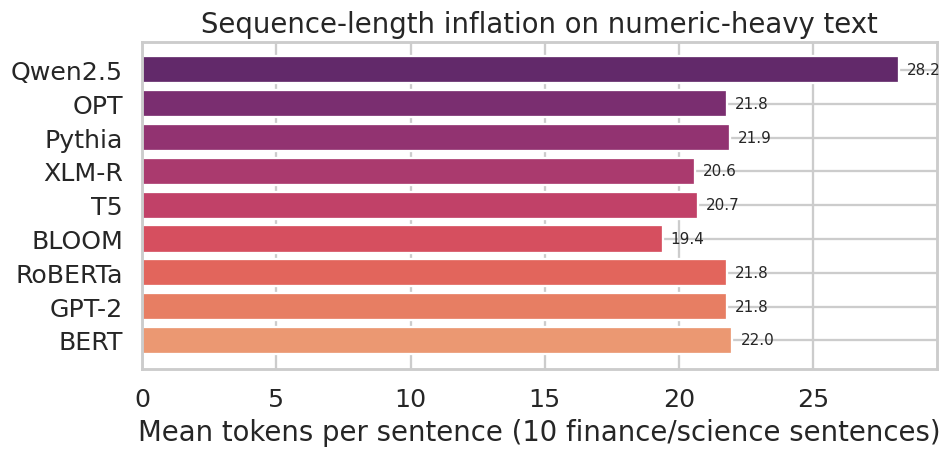

In [14]:
# Bar plot of the above
fig, ax = plt.subplots(figsize=(9, 4.5))
vals = real_summary["mean_tokens_per_sentence"].values
bars = ax.barh(real_summary.index, vals,
               color=sns.color_palette("flare", len(real_summary)))
for bar, v in zip(bars, vals):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.1f}", va="center", fontsize=10)
ax.set_xlabel("Mean tokens per sentence (10 finance/science sentences)")
ax.set_title("Sequence-length inflation on numeric-heavy text")
plt.tight_layout()
plt.savefig("fig_real_text_length.png", dpi=150, bbox_inches="tight")
plt.show()


The spread between tokenizers can easily be **1.5–2×** on numeric-heavy text — directly translating into that much more memory and compute per forward pass. For context-length-constrained scenarios (long financial filings, scientific papers) this matters a lot.


## 8. Save results for later notebooks

We persist the aggregated data so Notebook 2–4 can reference it and the poster can cite exact numbers.

In [15]:
import os
os.makedirs("results", exist_ok=True)

frag_df.to_csv("results/fragmentation_per_category.csv", index=False)
range_df.to_csv("results/integer_range_tokens.csv", index=False)
real_df.to_csv("results/real_text_lengths.csv", index=False)
mat.to_csv("results/fragmentation_matrix.csv")

print("Saved:")
for f in os.listdir("results"):
    print("  results/" + f)


Saved:
  results/real_text_lengths.csv
  results/fragmentation_per_category.csv
  results/integer_range_tokens.csv
  results/fragmentation_matrix.csv


## 9. Key findings

1. **Tokenization of numbers is highly non-uniform across tokenizer families.** The same integer can be 1 token (BERT, BLOOM) or 7+ tokens (Pythia) depending on the design.

2. **Surface form dominates.** `1000000` and `1,000,000` are semantically identical but fragment into very different token sequences on every non-digit-level tokenizer. Downstream models therefore treat them as effectively different inputs — a known source of brittleness.

3. **BPE-based tokenizers produce *irregular* fragmentation.** Token count does not scale linearly with magnitude. This kills the model's ability to generalize arithmetic learned on small numbers to large ones.

4. **Digit-level tokenization (Pythia / GPT-NeoX-style)** trades sequence length for regularity: every number has `len(str(n))` tokens. This is the design now used by LLaMA-3, Qwen-2.5, DeepSeek — precisely because it helps numerical reasoning (we test this directly in Notebook 2 and Notebook 4).

5. **Multilingual tokenizers (XLM-R, BLOOM)** do not consistently help with numbers — their large vocabularies *memorize* common numeric substrings but still fragment irregularly.

6. **Real-world numeric text gets 1.5–2× longer** under naively-trained tokenizers vs. digit-level ones on short texts, but digit-level tokenizers produce ~3× more tokens overall — so this trade-off is real and situation-dependent.

**Next up:** Notebook 2 checks whether these tokenization differences show up in the *embedding space* — can a model's number embeddings reconstruct magnitude?
